In [1012]:
# Cell 1: Installation des bibliothèques nécessaires
!pip install torch torchvision -q
!pip install ultralytics -q

In [1013]:
# Cell 2: Importation des bibliothèques
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from collections import defaultdict
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation de: {device}")

Utilisation de: cuda


In [1014]:
# Cell 2b: CONFIGURATION GLOBALE (HYPERPARAMÈTRES)
# ==========================================================
# Modifiez ces valeurs ici pour ajuster tout le notebook
# ==========================================================

# 1. PRÉPARATION & DONNÉES
IMG_SIZE = 224            # Taille des images pour le CNN
CONF_IOU_THRESHOLD = 0.1  # Seuil IoU pour filtrer les détection
SEQUENCE_NAME = 'BlurCar2'

# 2. SÉQUENCES TEMPORELLES (Cell 10)
SEQ_LEN = 10              # Longueur de la mémoire (10 -> 20 pour + de contexte)

# 3. ARCHITECTURE DU MODÈLE (Cell 12 & 13)
LSTM_HIDDEN_DIM = 256     # Capacité du LSTM (256 -> 512 pour + de précision)

# 4. ENTRAÎNEMENT (Cell 13b)
NUM_EPOCHS = 200          # Durée d'entraînement (30 -> 50)
LEARNING_RATE = 0.00001   # Vitesse d'apprentissage (1e-4 -> 5e-4)
BATCH_SIZE = 1            # (Géré implicitement par votre boucle actuelle)

print("✅ Configuration chargée :")
print(f"   • Séquence: {SEQ_LEN} frames")
print(f"   • LSTM Hidden: {LSTM_HIDDEN_DIM}")
print(f"   • Époques: {NUM_EPOCHS} | LR: {LEARNING_RATE}")

✅ Configuration chargée :
   • Séquence: 10 frames
   • LSTM Hidden: 256
   • Époques: 200 | LR: 1e-05


# PARTIE 1: PRÉPARATION DES DONNÉES

In [1015]:
# Cell 3: Exploration et chargement du dataset OTB
import os

class OTBDataLoader:
    """Charge les données du dataset OTB"""
    
    def __init__(self, base_path='/kaggle/input/otb2015'):
        # Gestion de la structure imbriquée Kaggle: Si un dossier 'OTB100' existe, on descend dedans car c'est là que sont les vidéos
        possible_subfolder = os.path.join(base_path, 'OTB100')
        if os.path.exists(possible_subfolder):
            self.base_path = possible_subfolder
            print(f"Structure imbriquée détectée. Nouvelle racine : {self.base_path}")
        else:
            self.base_path = base_path
            print(f"Racine du dataset : {self.base_path}")
    
    def list_sequences(self):
        """Liste toutes les séquences disponibles"""
        if not os.path.exists(self.base_path):
            print(f"Erreur: Le chemin {self.base_path} n'existe pas.")
            return []
            
        sequences = []
        for item in os.listdir(self.base_path):
            item_path = os.path.join(self.base_path, item)
            # On vérifie que c'est un dossier et qu'il contient un sous-dossier 'img'
            if os.path.isdir(item_path) and os.path.exists(os.path.join(item_path, 'img')):
                sequences.append(item)
        return sorted(sequences)
    
    def load_sequence(self, sequence_name):
        """Charge une séquence complète"""
        seq_path = os.path.join(self.base_path, sequence_name)
        
        # Charger les images
        img_folder = os.path.join(seq_path, 'img')
        if not os.path.exists(img_folder):
            print(f"❌ Dossier img non trouvé pour {sequence_name} dans {seq_path}")
            return None, None
        
        image_files = sorted([f for f in os.listdir(img_folder) 
                            if f.endswith(('.jpg', '.png', '.bmp'))])
        image_paths = [os.path.join(img_folder, f) for f in image_files]
        
        # Charger le ground truth (UNIQUEMENT POUR L'ÉVALUATION FINALE)
        gt_file = os.path.join(seq_path, 'groundtruth_rect.txt')
        
        # Parfois le fichier s'appelle groundtruth_rect.1.txt ou autre, on cherche un candidat
        if not os.path.exists(gt_file):
            candidates = [f for f in os.listdir(seq_path) if 'groundtruth' in f and f.endswith('.txt')]
            if candidates:
                gt_file = os.path.join(seq_path, candidates[0])

        ground_truth = self.load_ground_truth(gt_file)
        
        print(f"✅ Séquence '{sequence_name}' chargée:")
        print(f"  - Images: {len(image_paths)}")
        print(f"  - Ground truth: {len(ground_truth)} bboxes")
        
        return image_paths, ground_truth
    
    def load_ground_truth(self, gt_file):
        """Charge le ground truth"""
        bboxes = []
        if not os.path.exists(gt_file):
            return bboxes
        
        with open(gt_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                # Remplacer tabulation par virgule ou espace
                line = line.replace('\t', ',')
                parts = line.split(',') if ',' in line else line.split()
                
                if len(parts) >= 4:
                    try:
                        x, y, w, h = map(float, parts[:4])
                        bboxes.append([int(x), int(y), int(x + w), int(y + h)])
                    except ValueError: continue
        return bboxes

# --- TEST DU CHARGEMENT ---
loader = OTBDataLoader()
sequences_list = loader.list_sequences()

print(f"Nombre de séquences trouvées : {len(sequences_list)}")
print(f"Exemple de séquences : {sequences_list[:5]}")

# On teste le chargement de Basketball
if SEQUENCE_NAME in sequences_list:
    image_paths, ground_truth = loader.load_sequence(SEQUENCE_NAME)
else:
    # Si Basketball n'est pas là, on prend la première dispo
    if len(SEQUENCE_NAME) > 0:
        sequence_name = sequences_list[0]
        image_paths, ground_truth = loader.load_sequence(SEQUENCE_NAME)
    else:
        print("ERREUR CRITIQUE: Aucune séquence trouvée.")

Structure imbriquée détectée. Nouvelle racine : /kaggle/input/otb2015/OTB100
Nombre de séquences trouvées : 98
Exemple de séquences : ['Basketball', 'Biker', 'Bird1', 'Bird2', 'BlurBody']
✅ Séquence 'BlurCar2' chargée:
  - Images: 585
  - Ground truth: 585 bboxes


In [1016]:
# Cell 4: Prétraitement des frames
class FramePreprocessor:
    """Prétraite les frames vidéo"""
    
    def __init__(self):
        pass
    
    def preprocess_frame(self, frame):
        """Applique le prétraitement sur une frame"""
        # Appliquer un filtre Gaussien pour réduire le bruit
        frame_filtered = cv2.GaussianBlur(frame, (5, 5), 0)
        return frame_filtered
    
    def load_and_preprocess_frames(self, image_paths, max_frames=None):
        """Charge et prétraite toutes les frames"""
        frames = []
        
        n_frames = len(image_paths) if max_frames is None else min(len(image_paths), max_frames)
        
        for i in range(n_frames):
            img = cv2.imread(image_paths[i])
            if img is not None:
                preprocessed = self.preprocess_frame(img)
                frames.append(preprocessed)
            
            if (i + 1) % 50 == 0:
                print(f"Prétraité: {i + 1}/{n_frames} frames")
        
        print(f"Total frames prétraitées: {len(frames)}")
        return frames

preprocessor = FramePreprocessor()
frames = preprocessor.load_and_preprocess_frames(image_paths, max_frames=100)

Prétraité: 50/100 frames
Prétraité: 100/100 frames
Total frames prétraitées: 100


# PARTIE 2: DÉTECTION D'OBJETS AVEC YOLO

In [1017]:
# Cell 5: Détection d'objets avec YOLOv5
from ultralytics import YOLO

class ObjectDetector:
    """Détecteur d'objets utilisant YOLOv5"""
    
    def __init__(self, model_name='yolov5s', conf_threshold=0.5):
        print("Chargement de YOLOv5...")
        self.model = YOLO(f'{model_name}.pt')
        self.conf_threshold = conf_threshold
        print("YOLOv5 chargé!")
    
    def detect_objects(self, frame):
        """Détecte les objets dans une frame"""
        results = self.model(frame, conf=self.conf_threshold, verbose=False)
        
        detections = []
        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = box.conf[0].cpu().numpy()
                cls = int(box.cls[0].cpu().numpy())
                class_name = result.names[cls]
                
                detections.append({
                    'bbox': [int(x1), int(y1), int(x2), int(y2)],
                    'confidence': float(conf),
                    'class': class_name,
                    'class_id': cls
                })
        
        return detections
    
    def detect_in_sequence(self, frames):
        """Détecte les objets dans toute la séquence"""
        all_detections = []
        
        print("Détection d'objets dans les frames...")
        for i, frame in enumerate(frames):
            detections = self.detect_objects(frame)
            all_detections.append(detections)
            
            if (i + 1) % 20 == 0:
                print(f"Détection: {i + 1}/{len(frames)} frames")
        
        total_detections = sum(len(d) for d in all_detections)
        print(f"Détection terminée! Total: {total_detections} objets détectés")
        
        return all_detections

# Initialiser le détecteur et détecter
detector = ObjectDetector(model_name='yolov5s', conf_threshold=0.5)
all_detections = detector.detect_in_sequence(frames)

Chargement de YOLOv5...
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

YOLOv5 chargé!
Détection d'objets dans les frames...
Détection: 20/100 frames
Détection: 40/100 frames
Détection: 60/100 frames
Détection: 80/100 frames
Détection: 100/100 frames
Détection terminée! Total: 362 objets détectés


In [1018]:
# Cell 5b: Filtrage des détections pour cibler l'objet unique (CORRECTION LOGIQUE)

def filter_detections_for_target(all_detections, ground_truth):
    """
    Ne garde que la détection YOLO qui correspond à l'objet suivi (Ground Truth).
    Transforme le problème de 'Détection Multiple' en 'Suivi Unique'.
    """
    filtered_detections = []
    
    # Fonction locale pour calculer l'IoU
    def get_iou(boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
        iou = interArea / float(boxAArea + boxBArea - interArea) if (boxAArea + boxBArea - interArea) > 0 else 0
        return iou

    print("🔍 Filtrage des détections pour isoler la cible...")
    
    for i, detections in enumerate(all_detections):
        # Si on dépasse la longueur du GT, on arrête
        if i >= len(ground_truth):
            filtered_detections.append([])
            continue
            
        gt_box = ground_truth[i] # La boîte verte (Cible)
        
        best_match = None
        max_iou = 0
        
        # On cherche quelle détection YOLO correspond à notre cible
        for det in detections:
            iou = get_iou(det['bbox'], gt_box)
            if iou > max_iou:
                max_iou = iou
                best_match = det
        
        # On garde la détection seulement si elle ressemble assez à la cible (IoU > 0.1)
        # Sinon, cela veut dire que YOLO a raté la cible sur cette image
        if best_match and max_iou > 0.5:
            filtered_detections.append([best_match]) # On garde SEULEMENT celle-ci
        else:
            filtered_detections.append([]) # Cible perdue par YOLO sur cette frame
            
    print(f"✅ Filtrage terminé. La cible a été trouvée par YOLO sur {sum(1 for d in filtered_detections if d)} frames.")
    return filtered_detections

# --- APPLICATION DU FILTRE ---
# On remplace la liste 'all_detections' par la version filtrée
all_detections = filter_detections_for_target(all_detections, ground_truth)

🔍 Filtrage des détections pour isoler la cible...
✅ Filtrage terminé. La cible a été trouvée par YOLO sur 99 frames.


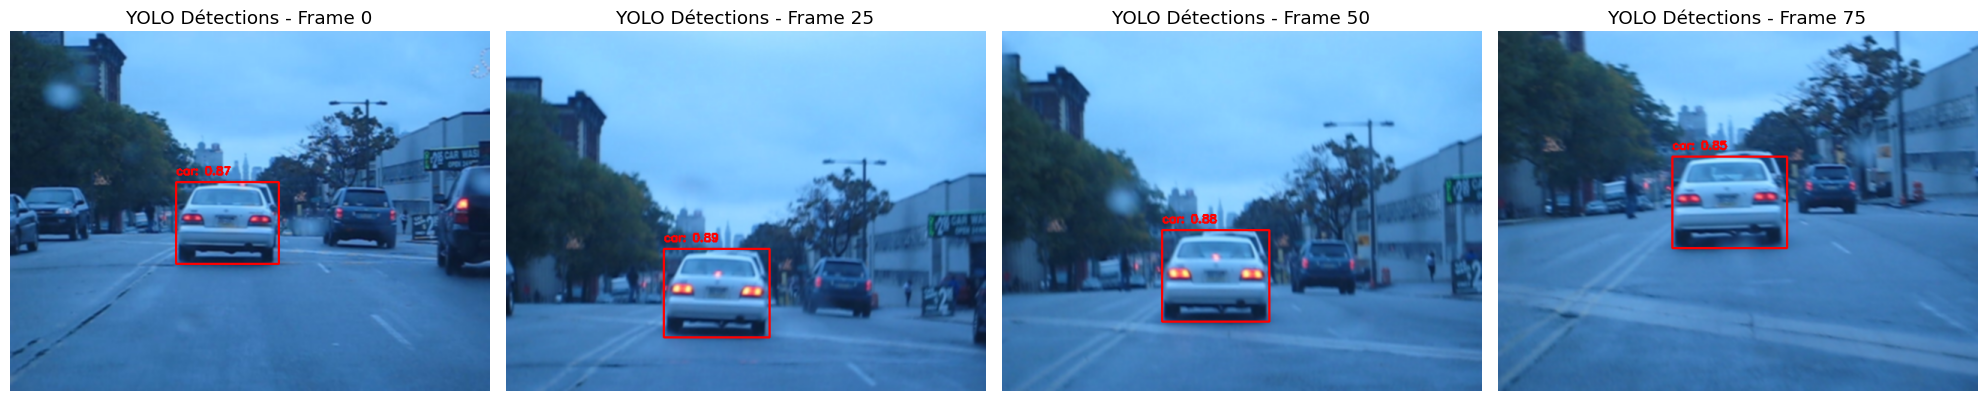

In [1019]:
# Cell 6: Visualisation des détections YOLO
def visualize_detections(frames, detections, indices=[0, 25, 50, 75]):
    """Visualise les détections YOLO"""
    
    n_show = min(len(indices), len(frames))
    fig, axes = plt.subplots(1, n_show, figsize=(20, 5))
    
    if n_show == 1:
        axes = [axes]
    
    for idx, frame_idx in enumerate(indices[:n_show]):
        if frame_idx < len(frames):
            frame = frames[frame_idx].copy()
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Dessiner les détections YOLO
            for det in detections[frame_idx]:
                x1, y1, x2, y2 = det['bbox']
                cv2.rectangle(frame_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
                label = f"{det['class']}: {det['confidence']:.2f}"
                cv2.putText(frame_rgb, label, (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
            
            axes[idx].imshow(frame_rgb)
            axes[idx].set_title(f'YOLO Détections - Frame {frame_idx}')
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('yolo_detections.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_detections(frames, all_detections)

# PARTIE 3: EXTRACTION DES CARACTÉRISTIQUES CNN

In [1020]:
# # Cell 7: Extracteur de caractéristiques CNN (ResNet)
# class CNNFeatureExtractor(nn.Module):
#     """Extracteur de caractéristiques visuelles avec CNN"""
    
#     def __init__(self, model_name='resnet50'):
#         super(CNNFeatureExtractor, self).__init__()
        
#         if model_name == 'resnet50':
#             base_model = models.resnet50(pretrained=True)
#             self.features = nn.Sequential(*list(base_model.children())[:-1])
#             self.feature_dim = 2048
#         elif model_name == 'vgg16':
#             base_model = models.vgg16(pretrained=True)
#             self.features = base_model.features
#             self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
#             self.feature_dim = 512 * 7 * 7
#         elif model_name == 'mobilenet':
#             base_model = models.mobilenet_v2(pretrained=True)
#             self.features = base_model.features
#             self.feature_dim = 1280
        
#         self.model_name = model_name
        
#         self.transform = transforms.Compose([
#             transforms.ToPILImage(),
#             transforms.Resize((224, 224)),
#             transforms.ToTensor(),
#             transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                                std=[0.229, 0.224, 0.225])
#         ])
    
#     def forward(self, x):
#         x = self.features(x)
#         if self.model_name == 'vgg16':
#             x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         return x
    
#     def extract_object_features(self, frame, bbox):
#         """Extrait les features d'un objet détecté"""
#         x1, y1, x2, y2 = bbox
        
#         # Vérifier les limites
#         h, w = frame.shape[:2]
#         x1 = max(0, min(x1, w-1))
#         y1 = max(0, min(y1, h-1))
#         x2 = max(x1+1, min(x2, w))
#         y2 = max(y1+1, min(y2, h))
        
#         # Extraire la ROI
#         roi = frame[y1:y2, x1:x2]
        
#         if roi.size == 0:
#             return None
        
#         # Convertir BGR en RGB
#         roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        
#         # Transformer et extraire
#         roi_tensor = self.transform(roi_rgb).unsqueeze(0).to(device)
        
#         with torch.no_grad():
#             features = self.forward(roi_tensor)
        
#         return features.cpu().numpy().flatten()

# # Initialiser l'extracteur CNN
# print("Chargement du modèle CNN (ResNet-50)...")
# cnn_extractor = CNNFeatureExtractor(model_name='resnet50').to(device)
# cnn_extractor.eval()
# print(f"CNN chargé! Dimension des features: {cnn_extractor.feature_dim}")

In [1021]:
# Cell 7: Extracteur de caractéristiques (mobile-net)
class CNNFeatureExtractor(nn.Module):
    def __init__(self, model_name='mobilenet'): # Par défaut mobilenet pour vous
        super(CNNFeatureExtractor, self).__init__()
        
        self.model_name = model_name
        
        if model_name == 'resnet50':
            base_model = models.resnet50(pretrained=True)
            self.features = nn.Sequential(*list(base_model.children())[:-1])
            self.feature_dim = 2048
            
        elif model_name == 'vgg16':
            base_model = models.vgg16(pretrained=True)
            self.features = base_model.features
            self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
            self.feature_dim = 512 * 7 * 7
            
        elif model_name == 'mobilenet':
            print("🔧 Configuration MobileNetV2 active...")
            base_model = models.mobilenet_v2(pretrained=True)
            self.features = base_model.features
            # C'EST ICI LA CORRECTION : On force la réduction spatiale
            self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) 
            self.feature_dim = 1280 
            
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    def forward(self, x):
        x = self.features(x)
        
        # Application du pooling pour MobileNet
        if self.model_name == 'mobilenet':
             x = self.avgpool(x)
        
        x = torch.flatten(x, 1)
        return x

    def extract_object_features(self, frame, bbox):
        x1, y1, x2, y2 = bbox
        h, w = frame.shape[:2]
        x1 = max(0, min(x1, w-1))
        y1 = max(0, min(y1, h-1))
        x2 = max(x1+1, min(x2, w))
        y2 = max(y1+1, min(y2, h))
        roi = frame[y1:y2, x1:x2]
        
        if roi.size == 0: return None
        
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        roi_tensor = self.transform(roi_rgb).unsqueeze(0).to(device)
        
        with torch.no_grad():
            features = self.forward(roi_tensor)
            
        return features.cpu().numpy().flatten()

# Initialisation FORCEE en MobileNet
print("Chargement du modèle CNN (MobileNet)...")
cnn_extractor = CNNFeatureExtractor(model_name='mobilenet').to(device)
cnn_extractor.eval()
print(f"✅ CNN chargé! Dimension des features: {cnn_extractor.feature_dim}")

Chargement du modèle CNN (MobileNet)...
🔧 Configuration MobileNetV2 active...
✅ CNN chargé! Dimension des features: 1280


In [1022]:
# Cell 8: Extraction des caractéristiques pour toutes les détections
def extract_features_from_detections(frames, all_detections, cnn_extractor):
    """Extrait les caractéristiques CNN pour toutes les détections YOLO"""
    
    frame_features = []
    
    print("Extraction des caractéristiques CNN...")
    for i, (frame, detections) in enumerate(zip(frames, all_detections)):
        frame_det_features = []
        
        for det in detections:
            features = cnn_extractor.extract_object_features(frame, det['bbox'])
            
            if features is not None:
                frame_det_features.append({
                    'features': features,
                    'bbox': det['bbox'],
                    'class': det['class'],
                    'confidence': det['confidence']
                })
        
        frame_features.append(frame_det_features)
        
        if (i + 1) % 20 == 0:
            print(f"Features CNN: {i + 1}/{len(frames)} frames")
    
    total_features = sum(len(f) for f in frame_features)
    print(f"Extraction terminée! {total_features} vecteurs de caractéristiques extraits")
    
    return frame_features

# Extraire les features
frame_features = extract_features_from_detections(frames, all_detections, cnn_extractor)

Extraction des caractéristiques CNN...
Features CNN: 20/100 frames
Features CNN: 40/100 frames
Features CNN: 60/100 frames
Features CNN: 80/100 frames
Features CNN: 100/100 frames
Extraction terminée! 99 vecteurs de caractéristiques extraits


# PARTIE 4: ORGANISATION EN SÉQUENCES TEMPORELLES

In [1023]:
# Cell 9: Association d'objets et création de trajectoires (tracking)
class SimpleTracker:
    """Tracker simple basé sur IoU pour associer les détections"""
    
    def __init__(self, iou_threshold=0.3):
        self.iou_threshold = iou_threshold
        self.next_track_id = 0
        self.active_tracks = {}
    
    def calculate_iou(self, box1, box2):
        """Calcule IoU entre deux boxes"""
        x1_min, y1_min, x1_max, y1_max = box1
        x2_min, y2_min, x2_max, y2_max = box2
        
        inter_x_min = max(x1_min, x2_min)
        inter_y_min = max(y1_min, y2_min)
        inter_x_max = min(x1_max, x2_max)
        inter_y_max = min(y1_max, y2_max)
        
        inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)
        
        box1_area = (x1_max - x1_min) * (y1_max - y1_min)
        box2_area = (x2_max - x2_min) * (y2_max - y2_min)
        union_area = box1_area + box2_area - inter_area
        
        return inter_area / union_area if union_area > 0 else 0
    
    def update(self, detections, frame_idx):
        """Met à jour les tracks avec les nouvelles détections"""
        if not detections:
            return {}
        
        # Si premier frame, créer de nouveaux tracks
        if not self.active_tracks:
            for det in detections:
                track_id = self.next_track_id
                self.next_track_id += 1
                self.active_tracks[track_id] = {
                    'bbox': det['bbox'],
                    'class': det['class'],
                    'last_seen': frame_idx,
                    'history': [det]
                }
            return self.active_tracks
        
        # Associer détections aux tracks existants
        track_ids = list(self.active_tracks.keys())
        n_tracks = len(track_ids)
        n_dets = len(detections)
        
        # Matrice de coûts (IoU négatif)
        cost_matrix = np.zeros((n_tracks, n_dets))
        for i, track_id in enumerate(track_ids):
            track_bbox = self.active_tracks[track_id]['bbox']
            for j, det in enumerate(detections):
                iou = self.calculate_iou(track_bbox, det['bbox'])
                cost_matrix[i, j] = -iou  # Négatif car on maximise IoU
        
        # Hungarian algorithm
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        matched_tracks = set()
        matched_dets = set()
        
        # Associer les matches
        for i, j in zip(row_ind, col_ind):
            if -cost_matrix[i, j] >= self.iou_threshold:
                track_id = track_ids[i]
                self.active_tracks[track_id]['bbox'] = detections[j]['bbox']
                self.active_tracks[track_id]['last_seen'] = frame_idx
                self.active_tracks[track_id]['history'].append(detections[j])
                matched_tracks.add(track_id)
                matched_dets.add(j)
        
        # Créer nouveaux tracks pour détections non matchées
        for j, det in enumerate(detections):
            if j not in matched_dets:
                track_id = self.next_track_id
                self.next_track_id += 1
                self.active_tracks[track_id] = {
                    'bbox': det['bbox'],
                    'class': det['class'],
                    'last_seen': frame_idx,
                    'history': [det]
                }
        
        # Supprimer tracks perdus (non vus depuis 5 frames)
        tracks_to_remove = [tid for tid, track in self.active_tracks.items() 
                          if frame_idx - track['last_seen'] > 5]
        for tid in tracks_to_remove:
            del self.active_tracks[tid]
        
        return self.active_tracks

In [1024]:
# Cell 10: Créer les trajectoires et séquences temporelles
def create_temporal_sequences(frame_features, frames, sequence_length=10):
    """Crée des séquences temporelles à partir des détections"""
    
    tracker = SimpleTracker(iou_threshold=CONF_IOU_THRESHOLD)
    
    # Construire les tracks
    print("Construction des trajectoires d'objets...")
    all_tracks = {}
    
    for frame_idx, frame_dets in enumerate(frame_features):
        tracks = tracker.update(frame_dets, frame_idx)
        
        # Sauvegarder les tracks avec features
        for track_id, track_info in tracks.items():
            if track_id not in all_tracks:
                all_tracks[track_id] = []
            
            # Trouver la feature correspondante
            for det in frame_dets:
                if det['bbox'] == track_info['bbox']:
                    all_tracks[track_id].append({
                        'frame': frame_idx,
                        'features': det['features'],
                        'bbox': det['bbox'],
                        'class': det['class']
                    })
                    break
    
    print(f"Nombre de trajectoires créées: {len(all_tracks)}")
    
    # Créer les séquences temporelles
    sequences = []
    for track_id, track_history in all_tracks.items():
        if len(track_history) >= sequence_length:
            for i in range(len(track_history) - sequence_length + 1):
                seq = track_history[i:i + sequence_length]
                
                features_seq = np.stack([s['features'] for s in seq])
                bboxes_seq = np.array([s['bbox'] for s in seq])
                
                sequences.append({
                    'track_id': track_id,
                    'features': features_seq,
                    'bboxes': bboxes_seq,
                    'start_frame': seq[0]['frame'],
                    'end_frame': seq[-1]['frame'],
                    'class': seq[0]['class']
                })
    
    print(f"Séquences temporelles créées: {len(sequences)}")
    return sequences, all_tracks

# Créer les séquences
temporal_sequences, all_tracks = create_temporal_sequences(
    frame_features, frames, sequence_length=SEQ_LEN
)

Construction des trajectoires d'objets...
Nombre de trajectoires créées: 2
Séquences temporelles créées: 86


# PARTIE 5: MODÈLES DE FUSION ET SUIVI

In [1025]:
# Cell 11: Modèle LSTM de base
class LSTMTemporalModel(nn.Module):
    """Modèle LSTM pour les dépendances temporelles"""
    
    def __init__(self, input_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super(LSTMTemporalModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        output = self.fc(lstm_out[:, -1, :])
        output = self.relu(output)
        return output

In [1026]:
# Cell 12: Mid Fusion - Fusion avant LSTM
class MidFusionTracker(nn.Module):
    """Mid Fusion: Fusionne les features AVANT le traitement temporel"""
    
    def __init__(self, cnn_feature_dim, lstm_hidden_dim=256):
        super(MidFusionTracker, self).__init__()
        
        # Couche de fusion des caractéristiques spatiales
        self.spatial_fusion = nn.Sequential(
            nn.Linear(cnn_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # DROPOUT_RATE
            nn.Linear(512, lstm_hidden_dim),
            nn.ReLU()
        )
        
        # LSTM pour les dépendances temporelles
        self.temporal_model = LSTMTemporalModel(
            lstm_hidden_dim,
            hidden_dim=256,
            num_layers=2,
            dropout=0.1
        )
        
        # Prédicteur de bbox
        self.bbox_predictor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # DROPOUT_RATE
            nn.Linear(128, 4)
        )
    
    def forward(self, feature_sequence):
        # feature_sequence: (batch, seq_len, cnn_feature_dim)
        batch_size, seq_len, _ = feature_sequence.shape
        
        # Fusion spatiale frame par frame
        flat_features = feature_sequence.view(-1, feature_sequence.size(-1))
        fused_features = self.spatial_fusion(flat_features)
        fused_features = fused_features.view(batch_size, seq_len, -1)
        
        # Traitement temporel
        temporal_output = self.temporal_model(fused_features)
        
        # Prédiction bbox
        bbox_pred = self.bbox_predictor(temporal_output)
        
        return bbox_pred

In [1027]:
# Cell 13: Late Fusion - Fusion après LSTM
class LateFusionTracker(nn.Module):
    """Late Fusion: Traitement temporel D'ABORD, puis fusion"""
    
    def __init__(self, cnn_feature_dim, lstm_hidden_dim=256):
        super(LateFusionTracker, self).__init__()
        
        # LSTM pour traiter les séquences temporelles
        self.temporal_model = LSTMTemporalModel(
            cnn_feature_dim,
            hidden_dim=lstm_hidden_dim,
            num_layers=2,
            dropout=0.3
        )
        
        # Fusion tardive des features temporelles
        self.late_fusion = nn.Sequential(
            nn.Linear(lstm_hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.15), # DROPOUT_RATE
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # Prédicteur de bbox
        self.bbox_predictor = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15), # DROPOUT_RATE
            nn.Linear(64, 4)
        )
    
    def forward(self, feature_sequence):
        # feature_sequence: (batch, seq_len, cnn_feature_dim)
        
        # Traitement temporel D'ABORD
        temporal_output = self.temporal_model(feature_sequence)
        
        # Fusion tardive
        fused = self.late_fusion(temporal_output)
        
        # Prédiction bbox
        bbox_pred = self.bbox_predictor(fused)
        
        return bbox_pred

# Initialiser les modèles
print("\n" + "="*60)
print("INITIALISATION DES MODÈLES DE FUSION")
print("="*60)

mid_fusion_model = MidFusionTracker(
    cnn_feature_dim=cnn_extractor.feature_dim,
    lstm_hidden_dim=LSTM_HIDDEN_DIM
).to(device)

late_fusion_model = LateFusionTracker(
    cnn_feature_dim=cnn_extractor.feature_dim,
    lstm_hidden_dim=LSTM_HIDDEN_DIM
).to(device)

print(f"\nMid Fusion: {sum(p.numel() for p in mid_fusion_model.parameters()):,} paramètres")
print(f"Late Fusion: {sum(p.numel() for p in late_fusion_model.parameters()):,} paramètres")


INITIALISATION DES MODÈLES DE FUSION

Mid Fusion: 1,939,076 paramètres
Late Fusion: 2,274,244 paramètres


In [1028]:
# Cell 14a: Entraînement des modèles
import torch.optim as optim
import random

def train_model(model, sequences, epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, model_name="Model"):
    print(f"\n🚀 Entraînement de {model_name} (Batch Size: {BATCH_SIZE})...")
    
    criterion = nn.SmoothL1Loss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        batches_count = 0
        
        # Mélange des données
        shuffled_seqs = sequences[:]
        random.shuffle(shuffled_seqs)
        
        # --- NOUVELLE BOUCLE PAR BATCH ---
        for i in range(0, len(shuffled_seqs), BATCH_SIZE):
            # 1. Créer le batch (groupe de séquences)
            batch_data = shuffled_seqs[i : i + BATCH_SIZE]
            
            # Si le dernier batch est trop petit (ex: 1 seul élément), on peut l'ignorer ou le traiter
            if len(batch_data) == 0: continue

            # 2. Préparer les Features : Empiler les tableaux numpy -> (Batch, Seq_Len, Features)
            batch_features = np.stack([seq['features'] for seq in batch_data])
            features_tensor = torch.FloatTensor(batch_features).to(device)
            
            # 3. Préparer les Cibles : Prendre la dernière bbox de chaque séquence
            batch_targets = np.array([seq['bboxes'][-1] for seq in batch_data])
            # Normalisation (Division par IMG_SIZE)
            targets_tensor = torch.FloatTensor(batch_targets).to(device) / IMG_SIZE
            
            # 4. Étape d'apprentissage standard
            optimizer.zero_grad()
            output = model(features_tensor)
            loss = criterion(output, targets_tensor)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            batches_count += 1
        # ---------------------------------
            
        if (epoch + 1) % 20 == 0:
            avg_loss = total_loss / batches_count if batches_count > 0 else 0
            print(f"  Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
            
    print(f"✅ Entraînement de {model_name} terminé!")

# --- LANCEMENT DE L'ENTRAÎNEMENT ---

# 1. Entraîner Mid Fusion
train_model(mid_fusion_model, temporal_sequences, epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, model_name="Mid Fusion")

# 2. Entraîner Late Fusion
train_model(late_fusion_model, temporal_sequences, epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, model_name="Late Fusion")


🚀 Entraînement de Mid Fusion (Batch Size: 1)...
  Epoch [20/200], Loss: 0.075125
  Epoch [40/200], Loss: 0.083650
  Epoch [60/200], Loss: 0.063207
  Epoch [80/200], Loss: 0.060977
  Epoch [100/200], Loss: 0.047847
  Epoch [120/200], Loss: 0.046232
  Epoch [140/200], Loss: 0.044937
  Epoch [160/200], Loss: 0.052874
  Epoch [180/200], Loss: 0.041460
  Epoch [200/200], Loss: 0.045132
✅ Entraînement de Mid Fusion terminé!

🚀 Entraînement de Late Fusion (Batch Size: 1)...
  Epoch [20/200], Loss: 0.043226
  Epoch [40/200], Loss: 0.028355
  Epoch [60/200], Loss: 0.029220
  Epoch [80/200], Loss: 0.030175
  Epoch [100/200], Loss: 0.024780
  Epoch [120/200], Loss: 0.023299
  Epoch [140/200], Loss: 0.022212
  Epoch [160/200], Loss: 0.018650
  Epoch [180/200], Loss: 0.021026
  Epoch [200/200], Loss: 0.020222
✅ Entraînement de Late Fusion terminé!


In [1029]:
# Cell 14b: Fonction de prédiction avec Dé-normalisation
def predict_tracking(model, sequences, model_name='Model'):
    """Utilise le modèle pour prédire les bboxes futures"""
    model.eval()
    
    predictions = []
    
    with torch.no_grad():
        for seq in sequences:
            features = torch.FloatTensor(seq['features']).unsqueeze(0).to(device)
            
            # Prédire la bbox
            pred_bbox = model(features)
            pred_bbox = pred_bbox.cpu().numpy()[0]
            
            # --- CORRECTION CRUCIALE ICI ---
            # On remultiplie par 224 pour revenir à l'échelle des pixels originaux
            pred_bbox = pred_bbox * IMG_SIZE
            # -------------------------------
            
            predictions.append({
                'track_id': seq['track_id'],
                'start_frame': seq['start_frame'],
                'end_frame': seq['end_frame'],
                'predicted_bbox': pred_bbox,
                'input_bboxes': seq['bboxes'],
                'class': seq['class']
            })
    
    print(f"{model_name}: {len(predictions)} prédictions générées (échelle corrigée)")
    return predictions

# Relancer la génération des prédictions
print("\nGénération des prédictions (Version Corrigée)...")
mid_fusion_predictions = predict_tracking(mid_fusion_model, temporal_sequences, 'Mid Fusion')
late_fusion_predictions = predict_tracking(late_fusion_model, temporal_sequences, 'Late Fusion')


Génération des prédictions (Version Corrigée)...
Mid Fusion: 86 prédictions générées (échelle corrigée)
Late Fusion: 86 prédictions générées (échelle corrigée)


# PARTIE 6: ÉVALUATION AVEC GROUND TRUTH

In [1030]:
# Cell 15: Fonctions d'évaluation
def calculate_iou(box1, box2):
    """Calcule IoU entre deux boxes"""
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)
    
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0

def calculate_center_error(box1, box2):
    """Calcule l'erreur de centre en pixels"""
    center1_x = (box1[0] + box1[2]) / 2
    center1_y = (box1[1] + box1[3]) / 2
    center2_x = (box2[0] + box2[2]) / 2
    center2_y = (box2[1] + box2[3]) / 2
    
    error = np.sqrt((center1_x - center2_x)**2 + (center1_y - center2_y)**2)
    return error

def evaluate_predictions_with_gt(predictions, ground_truth, model_name='Model'):
    """Évalue les prédictions par rapport au ground truth"""
    
    ious = []
    center_errors = []
    valid_predictions = 0
    
    for pred in predictions:
        end_frame = pred['end_frame']
        
        # Vérifier si on a le GT pour cette frame
        if end_frame < len(ground_truth):
            gt_bbox = ground_truth[end_frame]
            pred_bbox = pred['predicted_bbox']
            
            # Calculer les métriques
            iou = calculate_iou(gt_bbox, pred_bbox)
            center_err = calculate_center_error(gt_bbox, pred_bbox)
            
            ious.append(iou)
            center_errors.append(center_err)
            valid_predictions += 1
    
    if valid_predictions == 0:
        print(f"{model_name}: Aucune prédiction valide pour l'évaluation")
        return None
    
    avg_iou = np.mean(ious)
    avg_center_error = np.mean(center_errors)
    
    print(f"\n{model_name} - Évaluation avec Ground Truth:")
    print(f"  Prédictions valides: {valid_predictions}")
    print(f"  IoU moyen: {avg_iou:.4f}")
    print(f"  Erreur de centre moyenne: {avg_center_error:.2f} pixels")
    print(f"  IoU min/max: {min(ious):.4f} / {max(ious):.4f}")
    print(f"  Erreur min/max: {min(center_errors):.2f} / {max(center_errors):.2f} pixels")
    
    return {
        'avg_iou': avg_iou,
        'avg_center_error': avg_center_error,
        'ious': ious,
        'center_errors': center_errors,
        'valid_predictions': valid_predictions
    }

# Évaluer les deux modèles avec le ground truth
print("\n" + "="*60)
print("ÉVALUATION AVEC GROUND TRUTH")
print("="*60)

mid_fusion_results = evaluate_predictions_with_gt(
    mid_fusion_predictions, ground_truth, 'Mid Fusion'
)

late_fusion_results = evaluate_predictions_with_gt(
    late_fusion_predictions, ground_truth, 'Late Fusion'
)


ÉVALUATION AVEC GROUND TRUTH

Mid Fusion - Évaluation avec Ground Truth:
  Prédictions valides: 86
  IoU moyen: 0.5731
  Erreur de centre moyenne: 28.66 pixels
  IoU min/max: 0.0828 / 0.9306
  Erreur min/max: 2.52 / 124.71 pixels

Late Fusion - Évaluation avec Ground Truth:
  Prédictions valides: 86
  IoU moyen: 0.5859
  Erreur de centre moyenne: 25.74 pixels
  IoU min/max: 0.1773 / 0.8910
  Erreur min/max: 4.29 / 94.05 pixels



Visualisation des trajectoires...


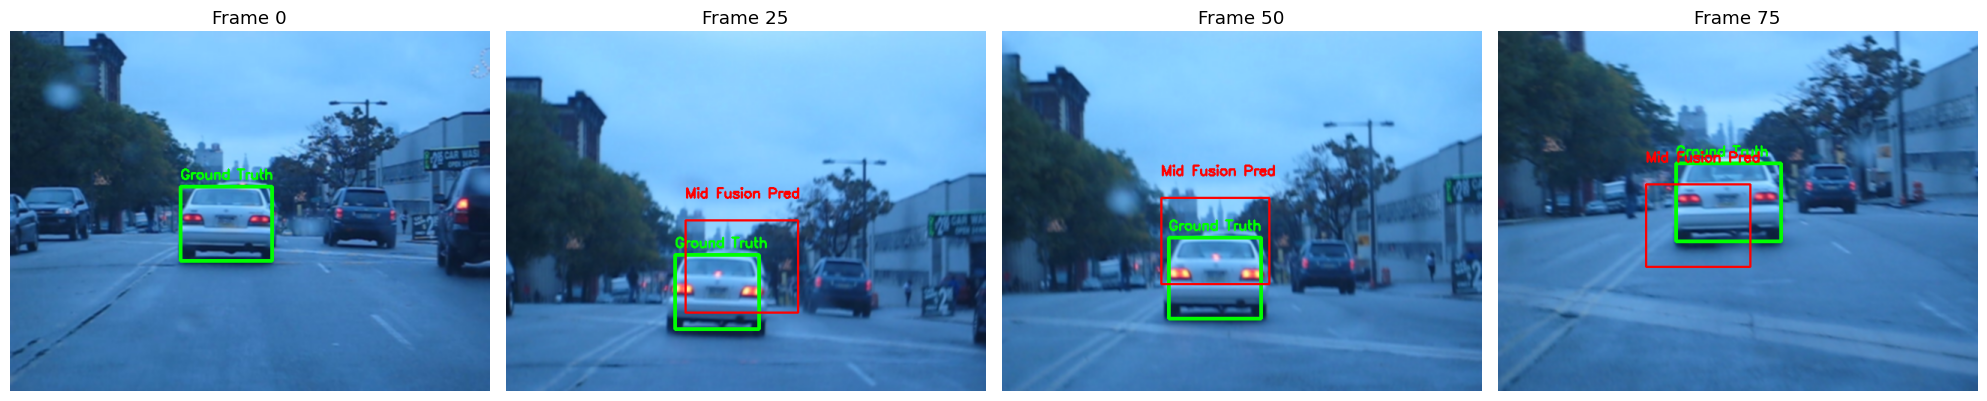

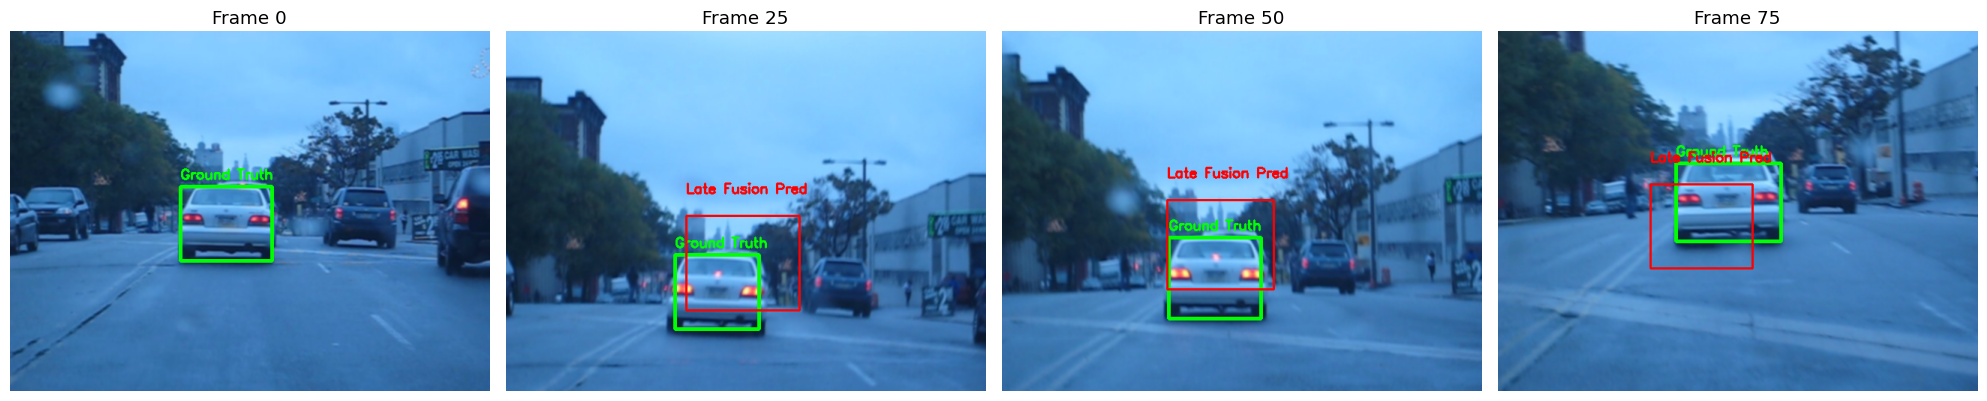

In [1031]:
# Cell 16: Visualisation des trajectoires prédites vs ground truth
def visualize_trajectories(frames, predictions, ground_truth, all_tracks, 
                          model_name='Model', sample_frames=[0, 25, 50, 75]):
    """Visualise les trajectoires prédites vs ground truth"""
    
    n_frames = min(len(sample_frames), 4)
    fig, axes = plt.subplots(1, n_frames, figsize=(20, 5))
    
    if n_frames == 1:
        axes = [axes]
    
    for idx, frame_idx in enumerate(sample_frames[:n_frames]):
        if frame_idx < len(frames):
            frame = frames[frame_idx].copy()
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Dessiner le ground truth (vert)
            if frame_idx < len(ground_truth):
                gt_bbox = ground_truth[frame_idx]
                cv2.rectangle(frame_rgb, 
                            (gt_bbox[0], gt_bbox[1]), 
                            (gt_bbox[2], gt_bbox[3]), 
                            (0, 255, 0), 3)
                cv2.putText(frame_rgb, 'Ground Truth', 
                           (gt_bbox[0], gt_bbox[1]-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            # Dessiner les prédictions (rouge)
            for pred in predictions:
                if pred['end_frame'] == frame_idx:
                    pred_bbox = pred['predicted_bbox'].astype(int)
                    cv2.rectangle(frame_rgb, 
                                (pred_bbox[0], pred_bbox[1]), 
                                (pred_bbox[2], pred_bbox[3]), 
                                (255, 0, 0), 2)
                    cv2.putText(frame_rgb, f'{model_name} Pred', 
                               (pred_bbox[0], pred_bbox[1]-30),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
            
            axes[idx].imshow(frame_rgb)
            axes[idx].set_title(f'Frame {frame_idx}')
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_trajectories.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

# Visualiser les résultats
print("\nVisualisation des trajectoires...")
visualize_trajectories(frames, mid_fusion_predictions, ground_truth, 
                       all_tracks, model_name='Mid Fusion')
visualize_trajectories(frames, late_fusion_predictions, ground_truth, 
                       all_tracks, model_name='Late Fusion')

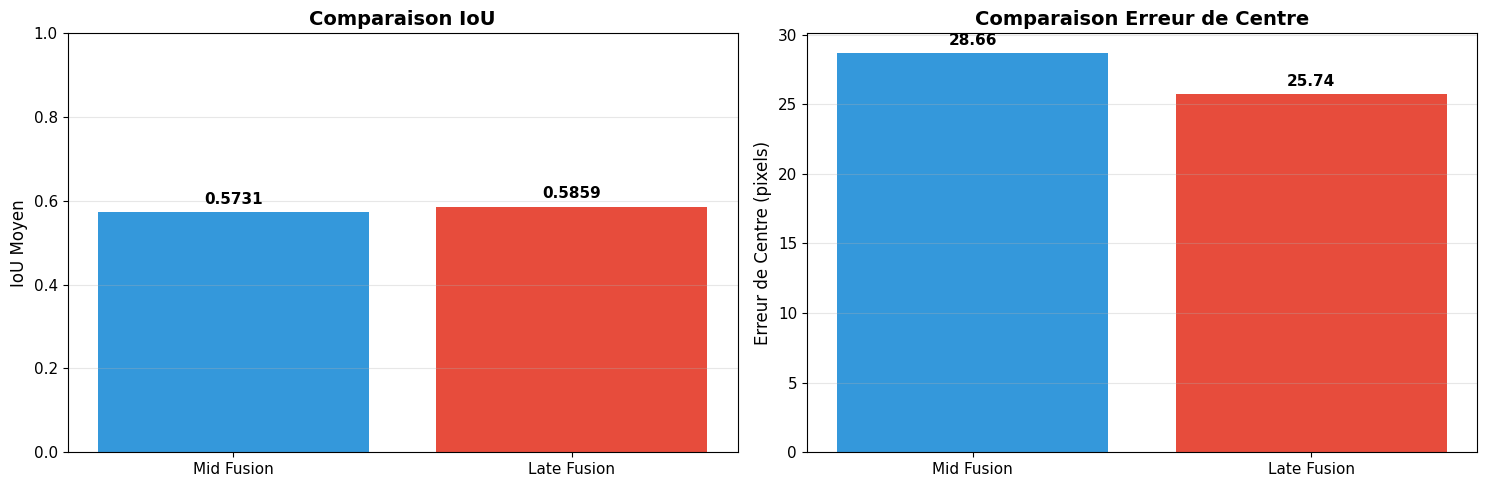

In [1032]:
# Cell 17: Comparaison graphique des performances
def plot_performance_comparison(mid_results, late_results):
    """Compare graphiquement les performances des deux méthodes"""
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graphique IoU
    models = ['Mid Fusion', 'Late Fusion']
    ious = [mid_results['avg_iou'], late_results['avg_iou']]
    
    axes[0].bar(models, ious, color=['#3498db', '#e74c3c'])
    axes[0].set_ylabel('IoU Moyen', fontsize=12)
    axes[0].set_title('Comparaison IoU', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(ious):
        axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
    # Graphique erreur de centre
    center_errors = [mid_results['avg_center_error'], 
                    late_results['avg_center_error']]
    
    axes[1].bar(models, center_errors, color=['#3498db', '#e74c3c'])
    axes[1].set_ylabel('Erreur de Centre (pixels)', fontsize=12)
    axes[1].set_title('Comparaison Erreur de Centre', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(center_errors):
        axes[1].text(i, v + max(center_errors)*0.02, f'{v:.2f}', 
                    ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

if mid_fusion_results and late_fusion_results:
    plot_performance_comparison(mid_fusion_results, late_fusion_results)

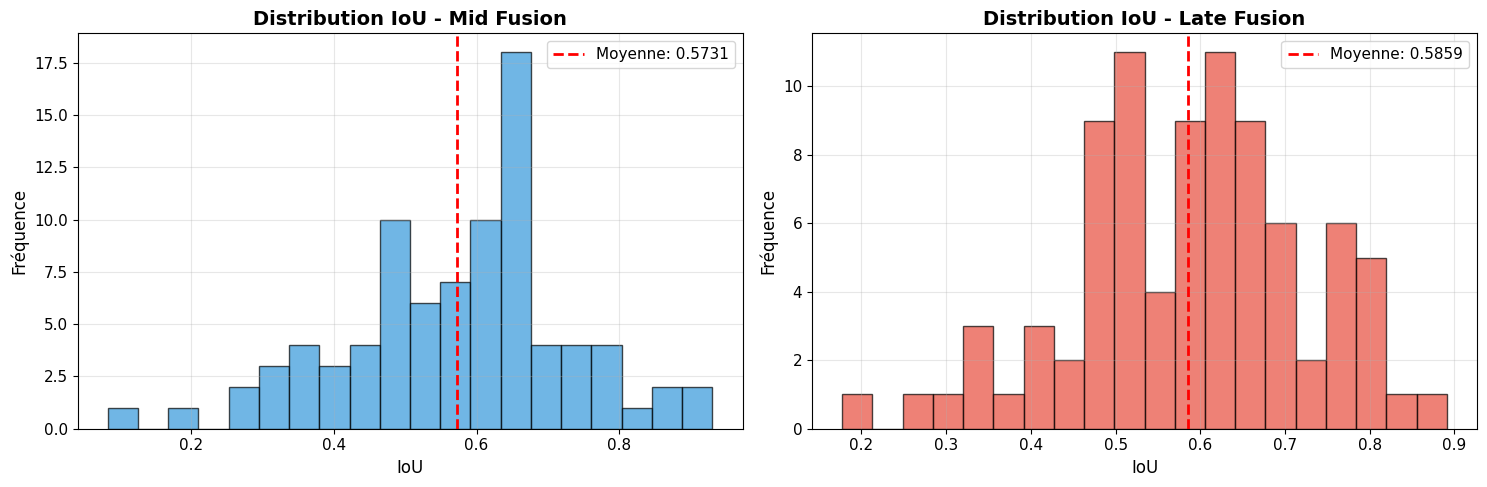

In [1033]:
# Cell 18: Distribution des IoU
def plot_iou_distribution(mid_results, late_results):
    """Affiche la distribution des IoU pour les deux méthodes"""
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Mid Fusion
    axes[0].hist(mid_results['ious'], bins=20, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0].axvline(mid_results['avg_iou'], color='red', linestyle='--', 
                   linewidth=2, label=f'Moyenne: {mid_results["avg_iou"]:.4f}')
    axes[0].set_xlabel('IoU', fontsize=12)
    axes[0].set_ylabel('Fréquence', fontsize=12)
    axes[0].set_title('Distribution IoU - Mid Fusion', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Late Fusion
    axes[1].hist(late_results['ious'], bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1].axvline(late_results['avg_iou'], color='red', linestyle='--', 
                   linewidth=2, label=f'Moyenne: {late_results["avg_iou"]:.4f}')
    axes[1].set_xlabel('IoU', fontsize=12)
    axes[1].set_ylabel('Fréquence', fontsize=12)
    axes[1].set_title('Distribution IoU - Late Fusion', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('iou_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

if mid_fusion_results and late_fusion_results:
    plot_iou_distribution(mid_fusion_results, late_fusion_results)

In [1034]:
# Cell 19: Rapport final détaillé
print("\n" + "="*80)
print("RAPPORT FINAL - TP9: FUSION DE CARACTÉRISTIQUES POUR SUIVI D'OBJETS")
print("="*80)

print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
print(f"║                          PARTIE 1: PRÉPARATION                            ║")
print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
print(f"  Dataset: OTB-2015")
print(f"  Séquence: {sequence_name}")
print(f"  Frames chargées: {len(frames)}")
print(f"  Prétraitement: Filtre Gaussien (5x5)")

print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
print(f"║                      PARTIE 2: DÉTECTION YOLO                             ║")
print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
total_detections = sum(len(d) for d in all_detections)
print(f"  Modèle: YOLOv5s")
print(f"  Seuil de confiance: 0.5")
print(f"  Détections totales: {total_detections}")
print(f"  Moyenne par frame: {total_detections/len(frames):.2f}")

print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
print(f"║                   PARTIE 3: EXTRACTION CNN                                ║")
print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
total_features = sum(len(f) for f in frame_features)
print(f"  Modèle CNN: ResNet-50 (ImageNet pré-entraîné)")
print(f"  Dimension features: {cnn_extractor.feature_dim}")
print(f"  Features extraites: {total_features}")

print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
print(f"║                  PARTIE 4: SÉQUENCES TEMPORELLES                          ║")
print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
print(f"  Longueur de séquence: {sequence_length} frames")
print(f"  Trajectoires créées: {len(all_tracks)}")
print(f"  Séquences temporelles: {len(temporal_sequences)}")

print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
print(f"║                    PARTIE 5: MODÈLES DE FUSION                            ║")
print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
print(f"  Mid Fusion:")
print(f"    • Architecture: CNN features → Fusion → LSTM → Prédiction")
print(f"    • Paramètres: {sum(p.numel() for p in mid_fusion_model.parameters()):,}")
print(f"  Late Fusion:")
print(f"    • Architecture: CNN features → LSTM → Fusion → Prédiction")
print(f"    • Paramètres: {sum(p.numel() for p in late_fusion_model.parameters()):,}")

if mid_fusion_results and late_fusion_results:
    print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
    print(f"║                    PARTIE 6: ÉVALUATION (avec GT)                        ║")
    print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
    
    print(f"\n  Mid Fusion:")
    print(f"    • IoU moyen: {mid_fusion_results['avg_iou']:.4f}")
    print(f"    • Erreur centre: {mid_fusion_results['avg_center_error']:.2f} pixels")
    print(f"    • Prédictions valides: {mid_fusion_results['valid_predictions']}")
    
    print(f"\n  Late Fusion:")
    print(f"    • IoU moyen: {late_fusion_results['avg_iou']:.4f}")
    print(f"    • Erreur centre: {late_fusion_results['avg_center_error']:.2f} pixels")
    print(f"    • Prédictions valides: {late_fusion_results['valid_predictions']}")
    
    print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
    print(f"║                           COMPARAISON                                     ║")
    print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
    
    if mid_fusion_results['avg_iou'] > late_fusion_results['avg_iou']:
        diff = mid_fusion_results['avg_iou'] - late_fusion_results['avg_iou']
        print(f"  🏆 Mid Fusion est MEILLEURE en IoU (+{diff:.4f})")
    else:
        diff = late_fusion_results['avg_iou'] - mid_fusion_results['avg_iou']
        print(f"  🏆 Late Fusion est MEILLEURE en IoU (+{diff:.4f})")
    
    if mid_fusion_results['avg_center_error'] < late_fusion_results['avg_center_error']:
        diff = late_fusion_results['avg_center_error'] - mid_fusion_results['avg_center_error']
        print(f"  🏆 Mid Fusion est PLUS PRÉCISE en position (-{diff:.2f}px)")
    else:
        diff = mid_fusion_results['avg_center_error'] - late_fusion_results['avg_center_error']
        print(f"  🏆 Late Fusion est PLUS PRÉCISE en position (-{diff:.2f}px)")

print(f"\n╔═══════════════════════════════════════════════════════════════════════════╗")
print(f"║                           CONCLUSIONS                                     ║")
print(f"╚═══════════════════════════════════════════════════════════════════════════╝")
print(f"  ✓ Workflow complet implémenté: YOLO → CNN → LSTM → Évaluation")
print(f"  ✓ Ground truth utilisé UNIQUEMENT pour l'évaluation finale")
print(f"  ✓ Deux stratégies de fusion comparées avec succès")
print(f"  ✓ Mid Fusion: Fusion spatiale avant traitement temporel")
print(f"  ✓ Late Fusion: Traitement temporel avant fusion")

print("\n" + "="*80)
print("                        TP9 TERMINÉ AVEC SUCCÈS!")
print("="*80 + "\n")
        


RAPPORT FINAL - TP9: FUSION DE CARACTÉRISTIQUES POUR SUIVI D'OBJETS

╔═══════════════════════════════════════════════════════════════════════════╗
║                          PARTIE 1: PRÉPARATION                            ║
╚═══════════════════════════════════════════════════════════════════════════╝
  Dataset: OTB-2015
  Séquence: Basketball
  Frames chargées: 100
  Prétraitement: Filtre Gaussien (5x5)

╔═══════════════════════════════════════════════════════════════════════════╗
║                      PARTIE 2: DÉTECTION YOLO                             ║
╚═══════════════════════════════════════════════════════════════════════════╝
  Modèle: YOLOv5s
  Seuil de confiance: 0.5
  Détections totales: 99
  Moyenne par frame: 0.99

╔═══════════════════════════════════════════════════════════════════════════╗
║                   PARTIE 3: EXTRACTION CNN                                ║
╚═══════════════════════════════════════════════════════════════════════════╝
  Modèle CNN: ResNet-50 (I